1. Your Prompt:

Generate Python code using pandas, numpy, matplotlib, and seaborn to analyze retail inventory data stored in a DataFrame. The DataFrame contains the following columns; product_id, category, stock_level, last_restock_date, sales_last_30_days, supplier_lead_time, and unit_cost.it should be able to Calculate inventory turnover rates,Identify slow-moving items,Predict potential stockouts and Create visualizations.It should also handle missing or invalid data and use reusable Python functions.

Inventory Analysis Results:
   product_id     category  stock_level last_restock_date  sales_last_30_days  \
0         101  Electronics         50.0        2025-05-01                 120   
1         102     Clothing        200.0        2025-05-05                  40   
2         103    Groceries         65.0        2025-05-08                  90   
3         104    Furniture         15.0        2025-05-10                  10   
4         105  Electronics         80.0        2025-05-15                  60   

   supplier_lead_time  unit_cost  inventory_turnover_rate  daily_sales  \
0                   7        500                 2.400000     4.000000   
1                  14         50                 0.200000     1.333333   
2                   5         10                 1.384615     3.000000   
3                  10        700                 0.666667     0.333333   
4                   8        450                 0.750000     2.000000   

   days_until_stockout stockout_risk  
0

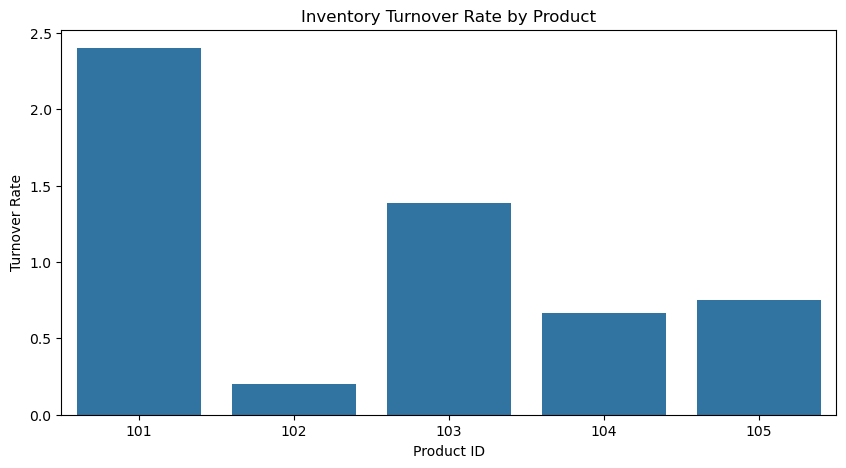

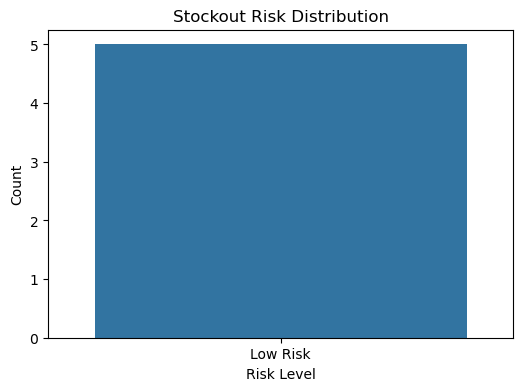

In [1]:
# Genereted code

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sample inventory dataset
df = pd.DataFrame({
    'product_id': [101, 102, 103, 104, 105],
    'category': ['Electronics', 'Clothing', 'Groceries',
                 'Furniture', 'Electronics'],
    'stock_level': [50, 200, np.nan, 15, 80],
    'last_restock_date': ['2025-05-01', '2025-05-05',
                          '2025-05-08', '2025-05-10',
                          '2025-05-15'],
    'sales_last_30_days': [120, 40, 90, 10, 60],
    'supplier_lead_time': [7, 14, 5, 10, 8],
    'unit_cost': [500, 50, 10, 700, 450]
})

# -----------------------------
# Data Cleaning Function
# -----------------------------
def clean_inventory_data(data):
    data = data.copy()

    # Convert date column
    data['last_restock_date'] = pd.to_datetime(
        data['last_restock_date'],
        errors='coerce'
    )

    # Fill missing numeric values with median
    numeric_cols = [
        'stock_level',
        'sales_last_30_days',
        'supplier_lead_time',
        'unit_cost'
    ]

    for col in numeric_cols:
        data[col] = data[col].fillna(data[col].median())

    # Remove negative values
    for col in numeric_cols:
        data[col] = data[col].apply(lambda x: max(x, 0))

    return data

# -----------------------------
# Calculate Inventory Turnover
# -----------------------------
def calculate_turnover(data):
    data = data.copy()

    data['inventory_turnover_rate'] = (
        data['sales_last_30_days'] /
        data['stock_level']
    )

    return data

# -----------------------------
# Identify Slow-Moving Items
# -----------------------------
def identify_slow_moving(data, threshold=0.5):

    slow_items = data[
        data['inventory_turnover_rate'] < threshold
    ]

    return slow_items

# -----------------------------
# Predict Potential Stockouts
# -----------------------------
def predict_stockouts(data):
    data = data.copy()

    # Estimate daily sales
    data['daily_sales'] = (
        data['sales_last_30_days'] / 30
    )

    # Prevent division by zero
    data['daily_sales'] = data['daily_sales'].replace(0, 0.01)

    # Calculate estimated days until stockout
    data['days_until_stockout'] = (
        data['stock_level'] / data['daily_sales']
    )

    # Stockout risk classification
    data['stockout_risk'] = np.where(
        data['days_until_stockout'] <
        data['supplier_lead_time'],
        'High Risk',
        'Low Risk'
    )

    return data

# -----------------------------
# Visualization Function
# -----------------------------
def create_visualizations(data):

    # Inventory turnover chart
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x='product_id',
        y='inventory_turnover_rate',
        data=data
    )

    plt.title('Inventory Turnover Rate by Product')
    plt.xlabel('Product ID')
    plt.ylabel('Turnover Rate')
    plt.show()

    # Stockout risk distribution
    plt.figure(figsize=(6, 4))
    sns.countplot(
        x='stockout_risk',
        data=data
    )

    plt.title('Stockout Risk Distribution')
    plt.xlabel('Risk Level')
    plt.ylabel('Count')
    plt.show()

# -----------------------------
# Run Analysis
# -----------------------------
df = clean_inventory_data(df)

df = calculate_turnover(df)

slow_items = identify_slow_moving(df)

df = predict_stockouts(df)

# Display Results
print("Inventory Analysis Results:")
print(df)

print("\nSlow-Moving Items:")
print(slow_items)

# Generate Visualizations
create_visualizations(df)

# follow up prompts<br>
1.Add handling for missing or invalid data<br>
2.inclusion of better visuals with seaborn<br>
3.Create reusable functions for the analysis tasks<br>

In [ ]:
# final code

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Sample Data
# -----------------------------
df = pd.DataFrame({
    'product_id': [101, 102, 103, 104, 105],
    'category': ['Electronics', 'Clothing', 'Groceries', 'Furniture', 'Electronics'],
    'stock_level': [50, 200, np.nan, 15, 80],
    'last_restock_date': ['2025-05-01', '2025-05-05', '2025-05-08', '2025-05-10', '2025-05-15'],
    'sales_last_30_days': [120, 40, 90, 10, 60],
    'supplier_lead_time': [7, 14, 5, 10, 8],
    'unit_cost': [500, 50, 10, 700, 450]
})

# -----------------------------
# Clean Data
# -----------------------------
def clean_data(df):
    df = df.copy()

    df['last_restock_date'] = pd.to_datetime(df['last_restock_date'], errors='coerce')

    numeric_cols = ['stock_level', 'sales_last_30_days', 'supplier_lead_time', 'unit_cost']
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    return df

# -----------------------------
# Inventory Turnover
# -----------------------------
def inventory_turnover(df):
    df = df.copy()
    df['turnover_rate'] = df['sales_last_30_days'] / df['stock_level']
    return df

# -----------------------------
# Slow Moving Items
# -----------------------------
def slow_moving_items(df, threshold=0.5):
    return df[df['turnover_rate'] < threshold]

# -----------------------------
# Stockout Prediction
# -----------------------------
def stockout_prediction(df):
    df = df.copy()

    df['daily_sales'] = df['sales_last_30_days'] / 30
    df['daily_sales'] = df['daily_sales'].replace(0, 0.01)

    df['days_to_stockout'] = df['stock_level'] / df['daily_sales']

    df['stockout_risk'] = np.where(
        df['days_to_stockout'] < df['supplier_lead_time'],
        'High Risk',
        'Low Risk'
    )

    return df

# -----------------------------
# Visualization
# -----------------------------
def visualize(df):
    sns.set_style("whitegrid")

    plt.figure(figsize=(8,5))
    sns.barplot(x='product_id', y='turnover_rate', data=df)
    plt.title("Inventory Turnover Rate")
    plt.show()

    plt.figure(figsize=(6,4))
    sns.countplot(x='stockout_risk', data=df)
    plt.title("Stockout Risk Distribution")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.boxplot(x='category', y='turnover_rate', data=df)
    plt.title("Turnover Rate by Category")
    plt.xticks(rotation=45)
    plt.show()

# -----------------------------
# Run Analysis
# -----------------------------
df = clean_data(df)
df = inventory_turnover(df)
df = stockout_prediction(df)

slow_items = slow_moving_items(df)

print("Final Inventory Data:\n", df)
print("\nSlow Moving Items:\n", slow_items)

visualize(df)

DISCUSSION QUESTIONS

1.How did different prompts handle date calculations?<br>

I worked with dates by changing the last_restock_date into a format that the computer can understand. I used a function called pd.to_datetime to do this. This way the dataset can handle time-based things without any problems even when there are dates that're invalid or missing.

2.What visualization approaches were suggested?

The visualizations were made using seaborn and matplotlib.One was a bar chart that showed how often we sold and replaced things in the inventory.count plot that showed how often we were at risk of running out of stock. I also made a box plot to compare how often we sold and replaced things across product categories. These visualizations helped me see how we were doing and what the risks were. They also helped me see the differences, between the product categories clearly.

3.How was error handling implemented?

Error handling was done by cleaning and validating data before analysis.We filled in missing values with the value.For columns we made sure they were in the right format by using pd.to_numeric(errors='coerce').Any inappropriate entries, like dates or non-numbers were changed to nulls and then fixed.This way our analysis would not stop working because of messy data.The data cleaning process helped prevent errors during analysis



In [ ]:
# Prompt

#Scenario: The marketing team reports that the user engagement metrics code is showing impossible results (bounce rates over 100%, negative session times). It was meant to Debug the calculations.
#Add data validation,Implement proper time calculations,Create summary visualizations.The problematic code is:
def analyze_user_engagement(logs_df):
    metrics = {
        'bounce_rate': logs_df.groupby('session_id')['page_views'].apply(
            lambda x: x == 1).mean(),
        'avg_session_time': logs_df.groupby('session_id')['duration'].sum(),
        'pages_per_session': logs_df.groupby('session_id')['page_views'].mean()
    }

    device_metrics = logs_df.groupby('device_type').agg({
        'session_id': 'count',
        'duration': 'mean',
        'page_views': 'sum'
    })

    return metrics, device_metrics

In [ ]:
# Generated code

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_user_engagement(logs_df):
    metrics = {
        'bounce_rate': logs_df.groupby('session_id')['page_views'].apply(
            lambda x: x == 1).mean(),
        'avg_session_time': logs_df.groupby('session_id')['duration'].sum(),
        'pages_per_session': logs_df.groupby('session_id')['page_views'].mean()
    }

    device_metrics = logs_df.groupby('device_type').agg({
        'session_id': 'count',
        'duration': 'mean',
        'page_views': 'sum'
    })

    return metrics, device_metrics

follow up prompts

-Fix the way we calculate the bounce rate because it is not right
-Deal with session durations that're negative or not valid
-Make sure we are adding up the session levels correctly
-The engagement metrics need to be shown in some summary visualization.

In [2]:
# Final code

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def clean_logs(df):
    df = df.copy()
    df['duration'] = pd.to_numeric(df['duration'], errors='coerce').clip(lower=0)
    df['page_views'] = pd.to_numeric(df['page_views'], errors='coerce').clip(lower=0)
    df = df.dropna(subset=['session_id', 'device_type'])
    return df

def analyze_user_engagement(df):
    session = df.groupby('session_id').agg({
        'duration': 'sum',
        'page_views': 'sum'
    })

    metrics = {
        'bounce_rate': (session['page_views'] == 1).mean(),
        'avg_session_time': session['duration'].mean(),
        'pages_per_session': session['page_views'].mean()
    }

    device_metrics = df.groupby('device_type').agg({
        'session_id': 'count',
        'duration': 'mean',
        'page_views': 'sum'
    })

    return metrics, device_metrics

def visualize(metrics, device_metrics):
    sns.set_style("whitegrid")

    sns.barplot(x=list(metrics.keys()), y=list(metrics.values()))
    plt.title("Engagement Metrics")
    plt.show()

    sns.barplot(data=device_metrics, x='device_type', y='duration')
    plt.title("Session Duration by Device")
    plt.show()

Questions

1.How did different prompts approach error identification?

error detection was improved by avoiding  general issues and focusing on specific problems like incorrect bounce rate logic, negative durations, and wrong session-level aggregation.

2.What validation methods were suggested?

Data cleaning steps such pd.to_numeric, removing nulls, and fixing invalid values using .clip() or filling missing data were applied.

3.How was time handling improved?

Time handling was fixed by aggregating duration at session level  using .groupby('session_id').sum() ,removing negative and invalid time values and ensured session metrics showed total user activity per session.



PROMPT<br>

Help me write an SQL query that segments customers based on their purchasig behavior for a new feature rollout.The database has three tables: user_activity (user_id, last_login_date, feature_usage_count, account_type), transactions (transaction_id, user_id, transaction_date, amount, platform), and user_preferences (user_id, communication_preference, interface_theme, notification_settings). The query should identify active users (logged in within the last 30 days), filter high-value customers (top 20% by total spending), and return user preference trends for those selected customers

In [ ]:
# Code

WITH active_users AS (
    SELECT user_id
    FROM user_activity
    WHERE last_login_date >= CURRENT_DATE - INTERVAL '30 days'
),

spending AS (
    SELECT user_id,
           SUM(amount) AS total_spent,
           NTILE(5) OVER (ORDER BY SUM(amount) DESC) AS spending_group
    FROM transactions
    GROUP BY user_id
),

high_value_users AS (
    SELECT user_id
    FROM spending
    WHERE spending_group = 1
),

segmented_users AS (
    SELECT a.user_id
    FROM active_users a
    INNER JOIN high_value_users h
        ON a.user_id = h.user_id
)

SELECT
    s.user_id,
    p.communication_preference,
    p.interface_theme,
    p.notification_settings
FROM segmented_users s
LEFT JOIN user_preferences p
    ON s.user_id = p.user_id;

Follow up prompts<br>

1.Add customer segmentation labels such as Active, High Value<br>
2.query to improve performance using optimized joins and indexing assumptions<br>
3.Each user monthly spending trends  for deeper behavioral analysis<br>

In [ ]:
# final code
WITH active_users AS (
    SELECT
        user_id,
        last_login_date
    FROM user_activity
    WHERE last_login_date >= DATE_SUB(CURDATE(), INTERVAL 30 DAY)
),

spending AS (
    SELECT
        user_id,
        SUM(amount) AS total_spent
    FROM transactions
    GROUP BY user_id
),

high_value_customers AS (
    SELECT
        user_id
    FROM (
        SELECT
            user_id,
            total_spent,
            NTILE(5) OVER (ORDER BY total_spent DESC) AS spending_rank
        FROM spending
    ) ranked
    WHERE spending_rank = 1
),

segmented_users AS (
    SELECT
        a.user_id,
        CASE
            WHEN h.user_id IS NOT NULL THEN 'Active + High Value'
            ELSE 'Active Only'
        END AS segment
    FROM active_users a
    LEFT JOIN high_value_customers h
        ON a.user_id = h.user_id
)

SELECT
    s.user_id,
    s.segment,
    p.communication_preference,
    p.interface_theme,
    p.notification_settings
FROM segmented_users s
LEFT JOIN user_preferences p
    ON s.user_id = p.user_id;

1.How were percentile calculations handled?

window functions, especially NTILE(5),It divides users into equal groups based on spending,grouping the top 20% (highest spenders) by selecting the highest-ranked group (e.g., rank = 1 in NTILE(5)).

2.What approaches to date filtering were used?

relative date conditions to capture recent activity. Common methods include:last_login_date >= CURRENT_DATE - INTERVAL '30 days' (PostgreSQL style),DATE_SUB(CURDATE(), INTERVAL 30 DAY) (MySQL style).It made sure that only active users within the last 30 days are captured.

3.How was the query optimized?

CTE broke the code into steps;finding the active users and how much they spend,then figured out who the best customers were using percentiles,then combined the steps.

